## Importing Libraries

In [1]:
import numpy as nop
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

## Ingesting Datasets

In [2]:
df_airlines = pd.read_csv('airlines.csv', dtype='str')
df_airports = pd.read_csv('airports.csv', dtype='str')
df_flights = pd.read_csv('flights.csv', dtype='str',nrows= 100000)

In [3]:
df_airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [4]:
df_airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [5]:
df_airports['COUNTRY'].value_counts(dropna=False)

COUNTRY
USA    322
Name: count, dtype: int64

In [6]:
df_flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,0020,0015,-5,15,0030,285,281,258,2342,0748,8,0805,0756,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,0025,0024,-1,11,0035,235,215,199,1448,0254,5,0320,0259,-21,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_flights.shape

(100000, 31)

## Merging airline and airports

In [8]:
df_flights = pd.merge(df_flights, df_airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')

In [9]:
df_flights.rename(columns={'AIRLINE_x':'AIRLINE_IATA'}, inplace=True)
df_flights.rename(columns={'AIRLINE_y':'AIRLINE'}, inplace=True)

In [10]:
df_flights.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE,AIRLINE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US,US Airways Inc.


In [11]:
df_flights = pd.merge(df_flights, df_airports[['IATA_CODE','AIRPORT','CITY','STATE']], left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')

In [12]:
df_flights.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE_x,AIRLINE,IATA_CODE_y,AIRPORT,CITY,STATE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.,ANC,Ted Stevens Anchorage International Airport,Anchorage,AK
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.,LAX,Los Angeles International Airport,Los Angeles,CA
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US,US Airways Inc.,SFO,San Francisco International Airport,San Francisco,CA


In [13]:
df_flights = pd.merge(df_flights, df_airports[['IATA_CODE','AIRPORT','CITY','STATE']], left_on='DESTINATION_AIRPORT', right_on='IATA_CODE', how='left')

In [14]:
df_flights.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE_x,AIRLINE,IATA_CODE_y,AIRPORT_x,CITY_x,STATE_x,IATA_CODE,AIRPORT_y,CITY_y,STATE_y
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.,ANC,Ted Stevens Anchorage International Airport,Anchorage,AK,SEA,Seattle-Tacoma International Airport,Seattle,WA
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.,LAX,Los Angeles International Airport,Los Angeles,CA,PBI,Palm Beach International Airport,West Palm Beach,FL
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US,US Airways Inc.,SFO,San Francisco International Airport,San Francisco,CA,CLT,Charlotte Douglas International Airport,Charlotte,NC


In [15]:
df_flights.rename(columns={'AIRPORT_x':'AIRPORT_ORG', 'CITY_x':'CITY_ORG', 'STATE_x':'STATE_ORG',
                          'AIRPORT_y':'AIRPORT_DST', 'CITY_y':'CITY_DST', 'STATE_y':'STATE_DST'}, inplace=True)

In [16]:
df_flights.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE_x,AIRLINE,IATA_CODE_y,AIRPORT_ORG,CITY_ORG,STATE_ORG,IATA_CODE,AIRPORT_DST,CITY_DST,STATE_DST
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.,ANC,Ted Stevens Anchorage International Airport,Anchorage,AK,SEA,Seattle-Tacoma International Airport,Seattle,WA
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.,LAX,Los Angeles International Airport,Los Angeles,CA,PBI,Palm Beach International Airport,West Palm Beach,FL
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US,US Airways Inc.,SFO,San Francisco International Airport,San Francisco,CA,CLT,Charlotte Douglas International Airport,Charlotte,NC


In [17]:
df_flights.drop(columns=['IATA_CODE_x','IATA_CODE_y','IATA_CODE'], axis=1, inplace=True)

In [18]:
df_flights.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE,AIRPORT_ORG,CITY_ORG,STATE_ORG,AIRPORT_DST,CITY_DST,STATE_DST
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,Seattle-Tacoma International Airport,Seattle,WA
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Palm Beach International Airport,West Palm Beach,FL
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US Airways Inc.,San Francisco International Airport,San Francisco,CA,Charlotte Douglas International Airport,Charlotte,NC
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,0020,0015,-5,15,0030,285,281,258,2342,0748,8,0805,0756,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Miami International Airport,Miami,FL
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,0025,0024,-1,11,0035,235,215,199,1448,0254,5,0320,0259,-21,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,Ted Stevens Anchorage International Airport,Anchorage,AK


In [19]:
df_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   YEAR                 100000 non-null  object
 1   MONTH                100000 non-null  object
 2   DAY                  100000 non-null  object
 3   DAY_OF_WEEK          100000 non-null  object
 4   AIRLINE_IATA         100000 non-null  object
 5   FLIGHT_NUMBER        100000 non-null  object
 6   TAIL_NUMBER          99833 non-null   object
 7   ORIGIN_AIRPORT       100000 non-null  object
 8   DESTINATION_AIRPORT  100000 non-null  object
 9   SCHEDULED_DEPARTURE  100000 non-null  object
 10  DEPARTURE_TIME       97702 non-null   object
 11  DEPARTURE_DELAY      97702 non-null   object
 12  TAXI_OUT             97629 non-null   object
 13  WHEELS_OFF           97629 non-null   object
 14  SCHEDULED_TIME       100000 non-null  object
 15  ELAPSED_TIME         97387 non-null

In [20]:
df = df_flights.copy()

In [21]:
df.describe().transpose()

,count,unique,top,freq
YEAR,100000,1,2015,100000
MONTH,100000,1,1,100000
DAY,100000,7,2,16741
DAY_OF_WEEK,100000,7,5,16741
AIRLINE_IATA,100000,14,WN,21160
FLIGHT_NUMBER,100000,6047,341,79
TAIL_NUMBER,99833,4190,N476HA,85
ORIGIN_AIRPORT,100000,312,ATL,6009
DESTINATION_AIRPORT,100000,312,ATL,6116
SCHEDULED_DEPARTURE,100000,1168,0600,2258


## Data Cleaning

In [22]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE_IATA', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'AIRLINE', 'AIRPORT_ORG',
       'CITY_ORG', 'STATE_ORG', 'AIRPORT_DST', 'CITY_DST', 'STATE_DST'],
      dtype='object')

In [23]:
# for i in df_flights.columns:
#     print(i, '\t', df_flights[i].unique(),'\n')

In [24]:
df.isna().sum().sort_values()

YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE_IATA               0
FLIGHT_NUMBER              0
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_TIME             0
SCHEDULED_DEPARTURE        0
SCHEDULED_ARRIVAL          0
AIRLINE                    0
CANCELLED                  0
DIVERTED                   0
DISTANCE                   0
AIRPORT_ORG                0
AIRPORT_DST                0
STATE_ORG                  0
STATE_DST                  0
CITY_DST                   0
CITY_ORG                   0
TAIL_NUMBER              167
DEPARTURE_TIME          2298
DEPARTURE_DELAY         2298
TAXI_OUT                2371
WHEELS_OFF              2371
ARRIVAL_TIME            2440
TAXI_IN                 2440
WHEELS_ON               2440
AIR_TIME                2613
ARRIVAL_DELAY           2613
ELAPSED_TIME            2613
AIR_SYSTEM_DELAY       65375
WEATHER_DELAY          65375
AIRLINE_DELAY 

In [25]:
df['CANCELLATION_REASON'].fillna('Not Cancelled', inplace=True)

C:\Users\Sharan Kalyan\AppData\Local\Temp\ipykernel_10792\2869090315.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CANCELLATION_REASON'].fillna('Not Cancelled', inplace=True)


In [26]:
df.isna().sum().sort_values()

YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE_IATA               0
FLIGHT_NUMBER              0
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_TIME             0
SCHEDULED_DEPARTURE        0
AIRLINE                    0
CANCELLATION_REASON        0
CANCELLED                  0
DIVERTED                   0
SCHEDULED_ARRIVAL          0
DISTANCE                   0
AIRPORT_DST                0
STATE_ORG                  0
STATE_DST                  0
CITY_DST                   0
CITY_ORG                   0
AIRPORT_ORG                0
TAIL_NUMBER              167
DEPARTURE_TIME          2298
DEPARTURE_DELAY         2298
TAXI_OUT                2371
WHEELS_OFF              2371
TAXI_IN                 2440
ARRIVAL_TIME            2440
WHEELS_ON               2440
ELAPSED_TIME            2613
AIR_TIME                2613
ARRIVAL_DELAY           2613
WEATHER_DELAY          65375
AIRLINE_DELAY 

In [27]:
df['DEPARTURE_TIME'].value_counts(dropna=False)

DEPARTURE_TIME
NaN     2298
0559     261
0557     239
0600     234
0558     233
        ... 
0336       1
0302       1
0325       1
0437       1
0447       1
Name: count, Length: 1356, dtype: int64

In [28]:
df = df.loc[df['CANCELLED']!='1']

In [29]:
len(df.loc[df['CANCELLED']=='1'])

0

In [30]:
df['CANCELLED'].value_counts()

CANCELLED
0    97611
Name: count, dtype: int64

In [31]:
df['ARRIVAL_TIME'].isnull().sum()

np.int64(51)

In [32]:
df.loc[df['ARRIVAL_TIME'].isnull()].head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE,AIRPORT_ORG,CITY_ORG,STATE_ORG,AIRPORT_DST,CITY_DST,STATE_DST
4639,2015,1,1,4,EV,4654,N29515,IAH,HRL,1125,1206,41,11,1217,75,NaN,NaN,295,NaN,NaN,1240,NaN,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Atlantic Southeast Airlines,George Bush Intercontinental Airport,Houston,TX,Valley International Airport,Harlingen,TX
7281,2015,1,1,4,EV,4654,N14543,CRP,HRL,1410,1736,206,9,1745,32,NaN,NaN,107,NaN,NaN,1442,NaN,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Atlantic Southeast Airlines,Corpus Christi International Airport,Corpus Christi,TX,Valley International Airport,Harlingen,TX
7508,2015,1,1,4,OO,5488,N791SK,IAH,ASE,1427,1436,9,19,1455,172,NaN,NaN,913,NaN,NaN,1619,NaN,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Skywest Airlines Inc.,George Bush Intercontinental Airport,Houston,TX,Aspen-Pitkin County Airport,Aspen,CO
11120,2015,1,1,4,OO,5203,N774SK,LAX,ASE,1816,1840,24,22,1902,128,NaN,NaN,737,NaN,NaN,2124,NaN,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Skywest Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Aspen-Pitkin County Airport,Aspen,CO
17275,2015,1,2,5,EV,2548,N905EV,DFW,BTR,0830,0824,-6,36,0900,80,NaN,NaN,383,NaN,NaN,0950,NaN,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Atlantic Southeast Airlines,Dallas/Fort Worth International Airport,Dallas-Fort Worth,TX,Baton Rouge Metropolitan Airport,Baton Rouge,LA


In [33]:
df['ARRIVAL_TIME'].dropna(axis=0, inplace=True)

In [34]:
df = df.loc[df['ARRIVAL_TIME'].notnull()]

In [35]:
df.shape

(97560, 38)

In [36]:
df['ARRIVAL_TIME'].isnull().sum()

np.int64(0)

In [37]:
df.isna().sum().sort_values()

YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE_IATA               0
FLIGHT_NUMBER              0
TAIL_NUMBER                0
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_DEPARTURE        0
DEPARTURE_TIME             0
DEPARTURE_DELAY            0
TAXI_OUT                   0
WHEELS_OFF                 0
SCHEDULED_TIME             0
DISTANCE                   0
AIRLINE                    0
WHEELS_ON                  0
TAXI_IN                    0
SCHEDULED_ARRIVAL          0
DIVERTED                   0
ARRIVAL_TIME               0
CANCELLATION_REASON        0
CANCELLED                  0
AIRPORT_DST                0
STATE_ORG                  0
STATE_DST                  0
CITY_DST                   0
CITY_ORG                   0
AIRPORT_ORG                0
ELAPSED_TIME             173
AIR_TIME                 173
ARRIVAL_DELAY            173
WEATHER_DELAY          62935
AIRLINE_DELAY 

In [38]:
df.loc[df['ELAPSED_TIME'].isnull()].head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE,AIRPORT_ORG,CITY_ORG,STATE_ORG,AIRPORT_DST,CITY_DST,STATE_DST
724,2015,1,1,4,DL,716,N944DL,OMA,ATL,0645,0637,-8,27,0704,144,NaN,NaN,821,1447,4,1009,1451,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Delta Air Lines Inc.,Eppley Airfield,Omaha,NE,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA
1455,2015,1,1,4,OO,5237,N712SK,MKE,IAH,0745,0742,-3,15,0757,176,NaN,NaN,984,1456,9,1041,1505,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Skywest Airlines Inc.,General Mitchell International Airport,Milwaukee,WI,George Bush Intercontinental Airport,Houston,TX
2218,2015,1,1,4,WN,1966,N685SW,ATL,JAX,0845,0922,37,9,0931,75,NaN,NaN,270,1214,5,1000,1219,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Southwest Airlines Co.,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA,Jacksonville International Airport,Jacksonville,FL
2526,2015,1,1,4,EV,4555,N12552,IAH,HRL,0902,0859,-3,33,0932,75,NaN,NaN,295,1314,5,1017,1319,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Atlantic Southeast Airlines,George Bush Intercontinental Airport,Houston,TX,Valley International Airport,Harlingen,TX
2866,2015,1,1,4,WN,1081,N214WN,MDW,OKC,0930,0926,-4,9,0935,125,NaN,NaN,691,1340,3,1135,1343,NaN,1,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Southwest Airlines Co.,Chicago Midway International Airport,Chicago,IL,Will Rogers World Airport,Oklahoma City,OK


In [39]:
df = df.loc[df['ELAPSED_TIME'].notnull()]

In [40]:
df.isna().sum().sort_values()

YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE_IATA               0
FLIGHT_NUMBER              0
TAIL_NUMBER                0
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_DEPARTURE        0
DEPARTURE_TIME             0
DEPARTURE_DELAY            0
TAXI_OUT                   0
WHEELS_OFF                 0
SCHEDULED_TIME             0
ELAPSED_TIME               0
AIR_TIME                   0
DISTANCE                   0
WHEELS_ON                  0
TAXI_IN                    0
SCHEDULED_ARRIVAL          0
ARRIVAL_TIME               0
ARRIVAL_DELAY              0
DIVERTED                   0
CANCELLED                  0
CANCELLATION_REASON        0
AIRLINE                    0
CITY_DST                   0
AIRPORT_DST                0
STATE_ORG                  0
CITY_ORG                   0
AIRPORT_ORG                0
STATE_DST                  0
WEATHER_DELAY          62762
AIRLINE_DELAY 

In [41]:
df.loc[df['WEATHER_DELAY'].isnull()].head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE,AIRPORT_ORG,CITY_ORG,STATE_ORG,AIRPORT_DST,CITY_DST,STATE_DST
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,Seattle-Tacoma International Airport,Seattle,WA
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Palm Beach International Airport,West Palm Beach,FL
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,US Airways Inc.,San Francisco International Airport,San Francisco,CA,Charlotte Douglas International Airport,Charlotte,NC
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,0020,0015,-5,15,0030,285,281,258,2342,0748,8,0805,0756,-9,0,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Miami International Airport,Miami,FL
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,0025,0024,-1,11,0035,235,215,199,1448,0254,5,0320,0259,-21,0,0,Not Cancelled,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,Ted Stevens Anchorage International Airport,Anchorage,AK


In [42]:
df.drop(columns=['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY'], axis=1, inplace=True)

In [43]:
df.isna().sum().sort_values()

YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE_IATA           0
FLIGHT_NUMBER          0
TAIL_NUMBER            0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_TIME         0
DEPARTURE_DELAY        0
TAXI_OUT               0
WHEELS_OFF             0
SCHEDULED_TIME         0
ELAPSED_TIME           0
AIR_TIME               0
DISTANCE               0
WHEELS_ON              0
TAXI_IN                0
SCHEDULED_ARRIVAL      0
ARRIVAL_TIME           0
ARRIVAL_DELAY          0
DIVERTED               0
CANCELLED              0
CANCELLATION_REASON    0
AIRLINE                0
AIRPORT_ORG            0
CITY_ORG               0
STATE_ORG              0
AIRPORT_DST            0
CITY_DST               0
STATE_DST              0
dtype: int64

In [44]:
df.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIRLINE,AIRPORT_ORG,CITY_ORG,STATE_ORG,AIRPORT_DST,CITY_DST,STATE_DST
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,Not Cancelled,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,Seattle-Tacoma International Airport,Seattle,WA
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,Not Cancelled,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Palm Beach International Airport,West Palm Beach,FL
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,Not Cancelled,US Airways Inc.,San Francisco International Airport,San Francisco,CA,Charlotte Douglas International Airport,Charlotte,NC


In [45]:
df['SCHEDULED_DEPARTURE'] = df['SCHEDULED_DEPARTURE'].astype('str').str.zfill(4)
df['SD_HOUR'] = df['SCHEDULED_DEPARTURE'].str[:2]
df['SD_MIN'] = df['SCHEDULED_DEPARTURE'].str[2:]

In [46]:
df.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIRLINE,AIRPORT_ORG,CITY_ORG,STATE_ORG,AIRPORT_DST,CITY_DST,STATE_DST,SD_HOUR,SD_MIN
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,Not Cancelled,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,Seattle-Tacoma International Airport,Seattle,WA,00,05
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,Not Cancelled,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Palm Beach International Airport,West Palm Beach,FL,00,10
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,Not Cancelled,US Airways Inc.,San Francisco International Airport,San Francisco,CA,Charlotte Douglas International Airport,Charlotte,NC,00,20


In [47]:
df['DEPARTURE_TIME'] = df['DEPARTURE_TIME'].astype('str').str.zfill(4)
df['DT_HOUR'] = df['DEPARTURE_TIME'].str[:2]
df['DT_MIN'] = df['DEPARTURE_TIME'].str[2:]

df['WHEELS_OFF'] = df['WHEELS_OFF'].astype('str').str.zfill(4)
df['WOFF_HOUR'] = df['WHEELS_OFF'].str[:2]
df['WOFF_MIN'] = df['WHEELS_OFF'].str[2:]

df['WHEELS_ON'] = df['WHEELS_ON'].astype('str').str.zfill(4)
df['WON_HOUR'] = df['WHEELS_ON'].str[:2]
df['WON_MIN'] = df['WHEELS_ON'].str[2:]

df['SCHEDULED_ARRIVAL'] = df['SCHEDULED_ARRIVAL'].astype('str').str.zfill(4)
df['SA_HOUR'] = df['SCHEDULED_ARRIVAL'].str[:2]
df['SA_MIN'] = df['SCHEDULED_ARRIVAL'].str[2:]

df['ARRIVAL_TIME'] = df['ARRIVAL_TIME'].astype('str').str.zfill(4)
df['AT_HOUR'] = df['ARRIVAL_TIME'].str[:2]
df['AT_MIN'] = df['ARRIVAL_TIME'].str[2:]

In [48]:
df.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIRLINE,AIRPORT_ORG,CITY_ORG,STATE_ORG,AIRPORT_DST,CITY_DST,STATE_DST,SD_HOUR,SD_MIN,DT_HOUR,DT_MIN,WOFF_HOUR,WOFF_MIN,WON_HOUR,WON_MIN,SA_HOUR,SA_MIN,AT_HOUR,AT_MIN
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,2354,-11,21,0015,205,194,169,1448,0404,4,0430,0408,-22,0,0,Not Cancelled,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,Seattle-Tacoma International Airport,Seattle,WA,00,05,23,54,00,15,04,04,04,30,04,08
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,0002,-8,12,0014,280,279,263,2330,0737,4,0750,0741,-9,0,0,Not Cancelled,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Palm Beach International Airport,West Palm Beach,FL,00,10,00,02,00,14,07,37,07,50,07,41
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,0018,-2,16,0034,286,293,266,2296,0800,11,0806,0811,5,0,0,Not Cancelled,US Airways Inc.,San Francisco International Airport,San Francisco,CA,Charlotte Douglas International Airport,Charlotte,NC,00,20,00,18,00,34,08,00,08,06,08,11


In [49]:
df.drop(columns=['SCHEDULED_DEPARTURE','DEPARTURE_TIME','WHEELS_OFF','WHEELS_ON','SCHEDULED_ARRIVAL','ARRIVAL_TIME'], axis=1, inplace=True)

In [50]:
df.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_IATA,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,TAXI_IN,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIRLINE,AIRPORT_ORG,CITY_ORG,STATE_ORG,AIRPORT_DST,CITY_DST,STATE_DST,SD_HOUR,SD_MIN,DT_HOUR,DT_MIN,WOFF_HOUR,WOFF_MIN,WON_HOUR,WON_MIN,SA_HOUR,SA_MIN,AT_HOUR,AT_MIN
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,-11,21,205,194,169,1448,4,-22,0,0,Not Cancelled,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,Seattle-Tacoma International Airport,Seattle,WA,00,05,23,54,00,15,04,04,04,30,04,08
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,-8,12,280,279,263,2330,4,-9,0,0,Not Cancelled,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Palm Beach International Airport,West Palm Beach,FL,00,10,00,02,00,14,07,37,07,50,07,41
2,2015,1,1,4,US,840,N171US,SFO,CLT,-2,16,286,293,266,2296,11,5,0,0,Not Cancelled,US Airways Inc.,San Francisco International Airport,San Francisco,CA,Charlotte Douglas International Airport,Charlotte,NC,00,20,00,18,00,34,08,00,08,06,08,11


In [51]:
df['YEAR'] = df['YEAR'].astype('int64')
df['MONTH'] = df['MONTH'].astype('int64')
df['DAY'] = df['DAY'].astype('int64')
df['DAY_OF_WEEK'] = df['DAY_OF_WEEK'].astype('int64')
df['FLIGHT_NUMBER'] = df['FLIGHT_NUMBER'].astype('int64')
df['DEPARTURE_DELAY'] = df['DEPARTURE_DELAY'].astype('int64')
df['TAXI_OUT'] = df['TAXI_OUT'].astype('int64')
df['SCHEDULED_TIME'] = df['SCHEDULED_TIME'].astype('int64')
df['ELAPSED_TIME'] = df['ELAPSED_TIME'].astype('int64')
df['AIR_TIME'] = df['AIR_TIME'].astype('int64')
df['DISTANCE'] = df['DISTANCE'].astype('int64')
df['TAXI_IN'] = df['TAXI_IN'].astype('int64')
df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].astype('int64')


In [52]:
df = df[['YEAR','MONTH','DAY','DAY_OF_WEEK','AIRLINE','AIRPORT_ORG','AIRPORT_DST','CITY_ORG','CITY_DST','STATE_ORG','STATE_DST',
         'FLIGHT_NUMBER','TAIL_NUMBER','ORIGIN_AIRPORT','DESTINATION_AIRPORT','SCHEDULED_TIME','SD_HOUR','SD_MIN',
         'SA_HOUR','SA_MIN','DISTANCE','ARRIVAL_DELAY']]

In [53]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,AIRPORT_ORG,AIRPORT_DST,CITY_ORG,CITY_DST,STATE_ORG,STATE_DST,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,SD_HOUR,SD_MIN,SA_HOUR,SA_MIN,DISTANCE,ARRIVAL_DELAY
0,2015,1,1,4,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Seattle-Tacoma International Airport,Anchorage,Seattle,AK,WA,98,N407AS,ANC,SEA,205,00,05,04,30,1448,-22
1,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Palm Beach International Airport,Los Angeles,West Palm Beach,CA,FL,2336,N3KUAA,LAX,PBI,280,00,10,07,50,2330,-9
2,2015,1,1,4,US Airways Inc.,San Francisco International Airport,Charlotte Douglas International Airport,San Francisco,Charlotte,CA,NC,840,N171US,SFO,CLT,286,00,20,08,06,2296,5
3,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Miami International Airport,Los Angeles,Miami,CA,FL,258,N3HYAA,LAX,MIA,285,00,20,08,05,2342,-9
4,2015,1,1,4,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Ted Stevens Anchorage International Airport,Seattle,Anchorage,WA,AK,135,N527AS,SEA,ANC,235,00,25,03,20,1448,-21


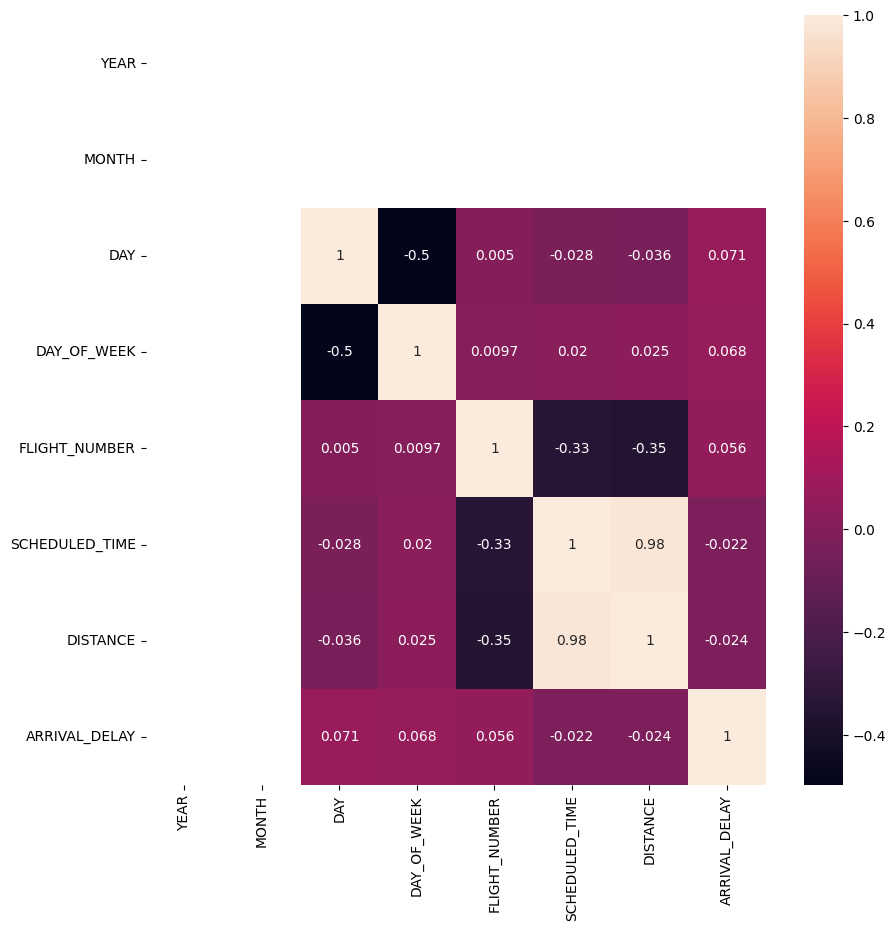

In [54]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [56]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,AIRPORT_ORG,AIRPORT_DST,CITY_ORG,CITY_DST,STATE_ORG,STATE_DST,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,SD_HOUR,SD_MIN,SA_HOUR,SA_MIN,DISTANCE,ARRIVAL_DELAY
0,2015,1,1,4,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Seattle-Tacoma International Airport,Anchorage,Seattle,AK,WA,98,N407AS,ANC,SEA,205,00,05,04,30,1448,-22
1,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Palm Beach International Airport,Los Angeles,West Palm Beach,CA,FL,2336,N3KUAA,LAX,PBI,280,00,10,07,50,2330,-9
2,2015,1,1,4,US Airways Inc.,San Francisco International Airport,Charlotte Douglas International Airport,San Francisco,Charlotte,CA,NC,840,N171US,SFO,CLT,286,00,20,08,06,2296,5
3,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Miami International Airport,Los Angeles,Miami,CA,FL,258,N3HYAA,LAX,MIA,285,00,20,08,05,2342,-9
4,2015,1,1,4,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Ted Stevens Anchorage International Airport,Seattle,Anchorage,WA,AK,135,N527AS,SEA,ANC,235,00,25,03,20,1448,-21


In [55]:
df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values()

AIRLINE
Virgin America                   4.092843
Alaska Airlines Inc.             4.407565
Delta Air Lines Inc.             4.911086
US Airways Inc.                 11.717997
Hawaiian Airlines Inc.          12.190189
Southwest Airlines Co.          18.134637
United Air Lines Inc.           18.621518
JetBlue Airways                 18.679047
Skywest Airlines Inc.           20.850349
Atlantic Southeast Airlines     23.102852
American Airlines Inc.          23.312554
Spirit Air Lines                28.011725
Frontier Airlines Inc.          35.219368
American Eagle Airlines Inc.    40.823638
Name: ARRIVAL_DELAY, dtype: float64

In [59]:
df.groupby(['FLIGHT_NUMBER'])['ARRIVAL_DELAY'].mean().sort_values()

FLIGHT_NUMBER
4023    -32.0
4014    -30.0
2655    -26.0
4694    -24.0
3006    -23.8
        ...  
3121    225.5
3666    272.5
3757    292.0
4280    361.0
6010    511.0
Name: ARRIVAL_DELAY, Length: 6037, dtype: float64

In [60]:
df.groupby(['DISTANCE'])['ARRIVAL_DELAY'].mean().sort_values()

DISTANCE
2874    -25.250000
2607    -19.846154
320     -17.280000
1965    -16.875000
2304    -16.666667
           ...    
3711     92.000000
1746     95.692308
464     112.000000
3784    129.375000
141     139.000000
Name: ARRIVAL_DELAY, Length: 1236, dtype: float64

In [64]:
df.groupby(['AIRPORT_ORG','AIRPORT_DST','DISTANCE','FLIGHT_NUMBER'])['ARRIVAL_DELAY'].sum().sort_values()

AIRPORT_ORG                                                             AIRPORT_DST                                   DISTANCE  FLIGHT_NUMBER
Seattle-Tacoma International Airport                                    Tampa International Airport                   2520      774              -274
Kona International Airport at Keahole                                   Portland International Airport                2607      802              -222
Portland International Airport                                          Minneapolis-Saint Paul International Airport  1426      2090             -199
Hartsfield-Jackson Atlanta International Airport                        San Francisco International Airport           2139      2049             -193
Ted Stevens Anchorage International Airport                             Seattle-Tacoma International Airport          1448      1560             -193
                                                                                                            

In [70]:
df[['AIRPORT_ORG']].value_counts().sort_values(ascending=False)

AIRPORT_ORG                                             
Hartsfield-Jackson Atlanta International Airport            5958
Dallas/Fort Worth International Airport                     4572
Chicago O'Hare International Airport                        4562
Denver International Airport                                3766
Los Angeles International Airport                           3732
                                                            ... 
Kodiak Airport                                                 5
Grand Forks International Airport                              4
Southwest Oregon Regional Airport (North Bend Municipal)       3
Pago Pago International Airport (Tafuna Airport)               2
Adak Airport                                                   2
Name: count, Length: 312, dtype: int64

In [72]:
df[['AIRPORT_DST']].value_counts().sort_values(ascending=False).head(30)

AIRPORT_DST                                                           
Hartsfield-Jackson Atlanta International Airport                          6070
Dallas/Fort Worth International Airport                                   4678
Chicago O'Hare International Airport                                      4637
Denver International Airport                                              3802
Los Angeles International Airport                                         3713
George Bush Intercontinental Airport                                      2887
Phoenix Sky Harbor International Airport                                  2841
San Francisco International Airport                                       2810
McCarran International Airport                                            2350
Orlando International Airport                                             2153
Charlotte Douglas International Airport                                   1933
Salt Lake City International Airport                        